# ML Prediction Using XGBoost and LightGBM

In [2]:
import pandas as pd

# load dataset
data = pd.read_csv("diabetes.csv")

# display first rows
print(data.head())

# dataset information
print(data.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [5]:
# check missing values
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
print((data == 0).sum())

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


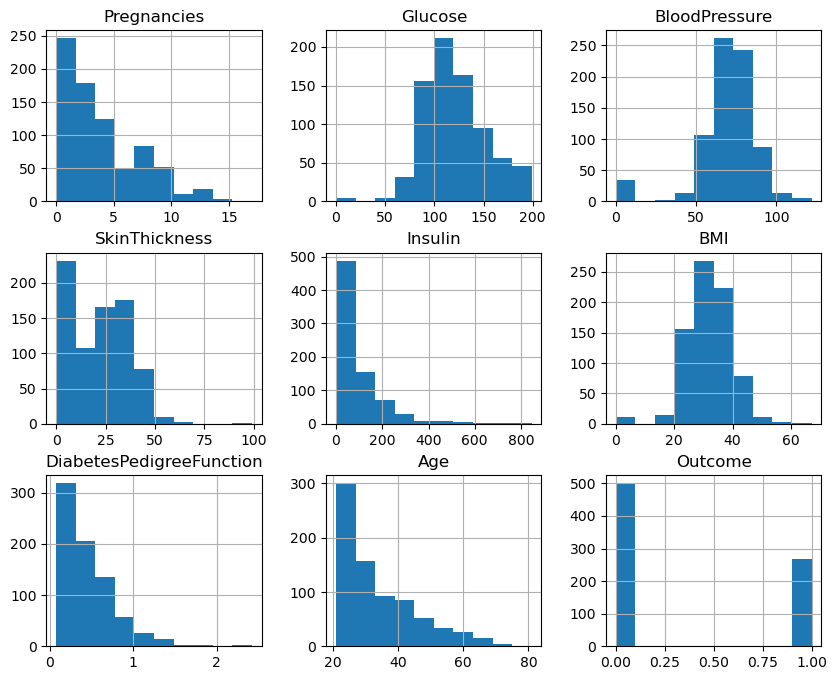

In [7]:
import matplotlib.pyplot as plt

data.hist(figsize=(10,8))
plt.show()

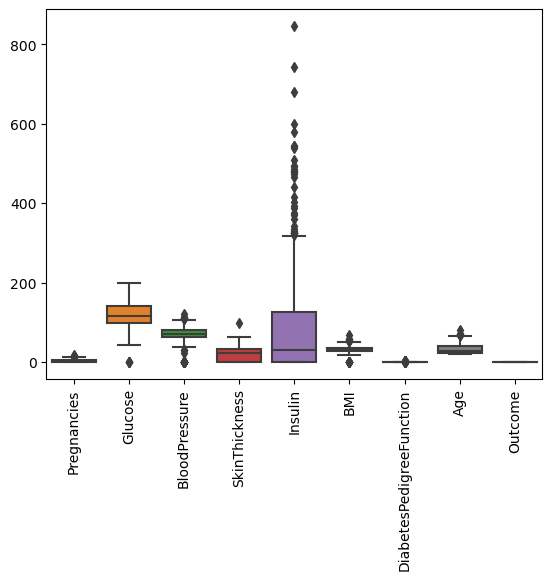

In [8]:
import seaborn as sns

sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

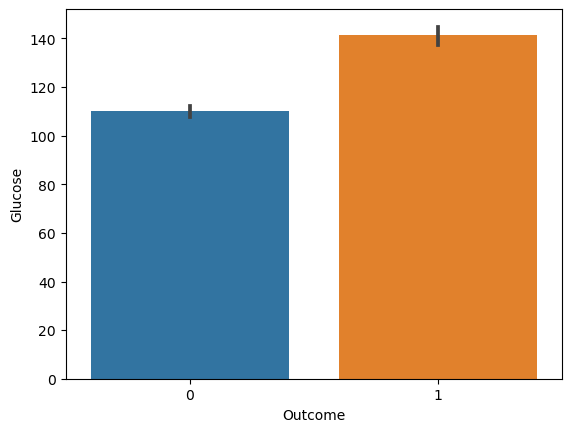

In [9]:
sns.barplot(x="Outcome", y="Glucose", data=data)
plt.show()

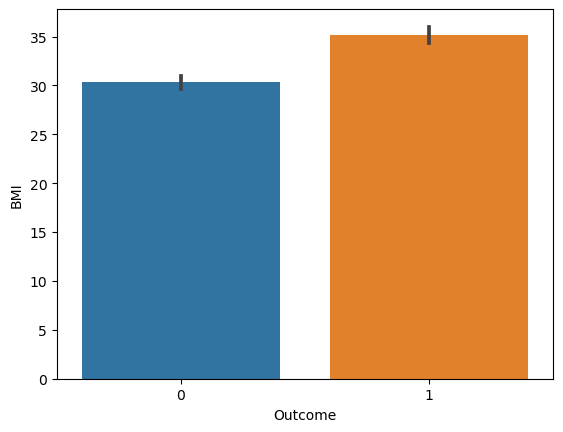

In [10]:
sns.barplot(x="Outcome", y="BMI", data=data)
plt.show()

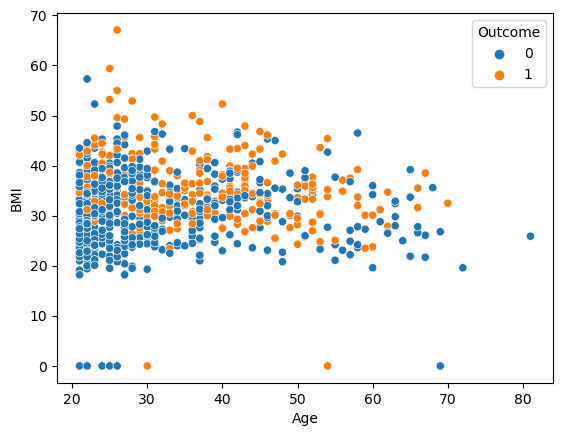

In [11]:
sns.scatterplot(x="Age", y="BMI", hue="Outcome", data=data)
plt.show()

# Data Preprocessing:

In [12]:
import pandas as pd
import numpy as np

data = pd.read_csv("diabetes.csv")

cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols:
    data[col] = data[col].replace(0, np.nan)
    data[col].fillna(data[col].median(), inplace=True)

In [13]:
print(data.dtypes)

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Building Predictive Models

In [16]:
from sklearn.model_selection import train_test_split

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (614, 8)
Testing size: (154, 8)


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [18]:
!pip install lightgbm
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.5 MB 653.6 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.5 MB 1.2 MB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.5 MB 2.3 MB/s eta 0:00:01
   ---------------- ----------------------- 0.6/1.5 MB 3.1 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.5 MB 3.5 MB/s eta 0:00:01
   -------------------------- ------------- 1.0/1.5 MB 3.2 MB/s eta 0:00:01
   ------------------------------- -------- 1.2/1.5 MB 3.3 MB/s eta 0:00:01
   --------------------------------- ------

In [19]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier()

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [20]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

C:\Users\user\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:38:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
print("LightGBM Results")
print("Accuracy:", accuracy_score(y_test, lgb_pred))
print("Precision:", precision_score(y_test, lgb_pred))
print("Recall:", recall_score(y_test, lgb_pred))
print("F1 Score:", f1_score(y_test, lgb_pred))


print("\nXGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))

LightGBM Results
Accuracy: 0.7207792207792207
Precision: 0.6
Recall: 0.6545454545454545
F1 Score: 0.6260869565217392

XGBoost Results
Accuracy: 0.7142857142857143
Precision: 0.5873015873015873
Recall: 0.6727272727272727
F1 Score: 0.6271186440677966


In [22]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

C:\Users\user\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:38:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\user\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:38:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\user\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:38:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Cross Validation Scores: [0.74675325 0.72077922 0.72727273 0.79738562 0.73202614]
Average Score: 0.7448433919022154


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:38:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\user\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:38:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [23]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth":[3,4,5],
    "learning_rate":[0.01,0.1],
    "n_estimators":[100,200]
}

grid = GridSearchCV(XGBClassifier(eval_metric='logloss'), params, cv=3)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}


# Comparative Analysis

In [24]:
#Compare Performance Metrics of LightGBM and XGBoost
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# LightGBM metrics
lgb_accuracy = accuracy_score(y_test, lgb_pred)
lgb_precision = precision_score(y_test, lgb_pred)
lgb_recall = recall_score(y_test, lgb_pred)
lgb_f1 = f1_score(y_test, lgb_pred)

# XGBoost metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

results = pd.DataFrame({
    "Model":["LightGBM","XGBoost"],
    "Accuracy":[lgb_accuracy,xgb_accuracy],
    "Precision":[lgb_precision,xgb_precision],
    "Recall":[lgb_recall,xgb_recall],
    "F1 Score":[lgb_f1,xgb_f1]
})

print(results)

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.720779   0.600000  0.654545  0.626087
1   XGBoost  0.714286   0.587302  0.672727  0.627119


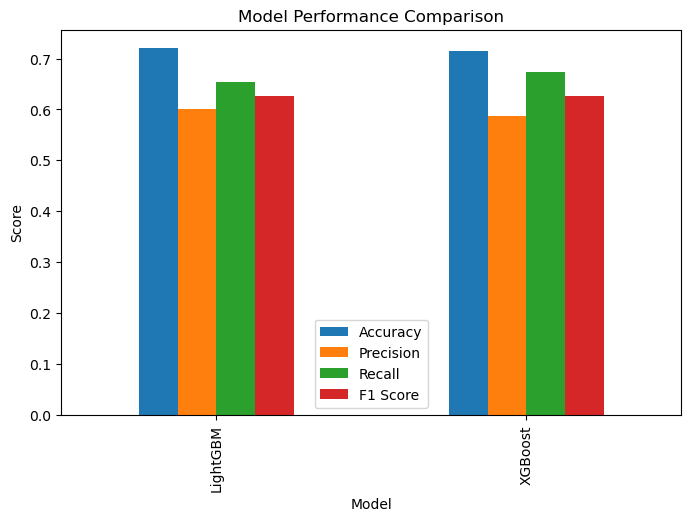

In [25]:
#Visualize Model Performance
import matplotlib.pyplot as plt

results.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()